# Label Analysis of Datasets

Shape: (69298, 2)

Columns: ['text', 'label']

Sample rows:
                                                text    label
0  Layin n bed with a headache  ughhhh...waitin o...  sadness
1                Funeral ceremony...gloomy friday...  sadness
2  @dannycastillo We want to trade with someone w...  neutral
3  I should be sleep, but im not! thinking about ...  sadness
4            @charviray Charlene my love. I miss you  sadness

Class Distribution:
label
neutral     24659
sadness     13029
joy         10076
love         7402
anger        6567
surprise     3933
fear         3632
Name: count, dtype: int64


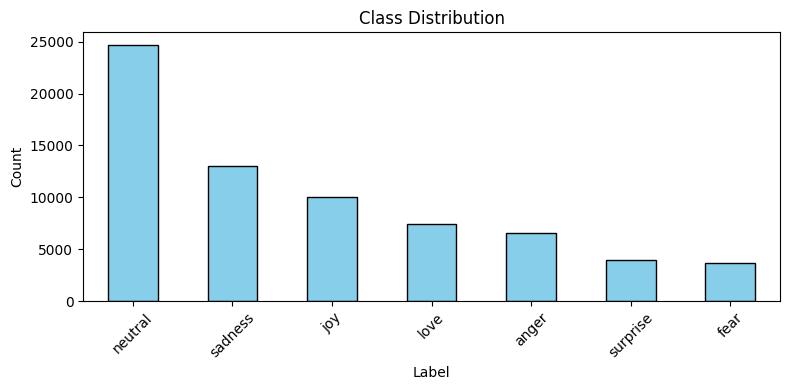

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/text-sentiment/main.csv")

# Display basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample rows:")
print(df.head())

# Check class distribution
print("\nClass Distribution:")
print(df['label'].value_counts())

# Optionally visualize it
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Available sheets: ['List1']
Shape: (7666, 2)

Columns: ['Field1', 'SIT']

Sample rows:
  Field1                                                SIT
0  anger  When a boy tried to fool me so he would be OK ...
1  anger  I felt anger when I saw that I was being misle...
2  anger  Once a friend had pushed me and I had fallen o...
3  anger  When I was misleaded by a person who assured t...
4  anger  I don't use to lie to my parets about what I d...

Class Distribution:
Field1
anger      1096
disgust    1096
sadness    1096
shame      1096
fear       1095
joy        1094
guilt      1093
Name: count, dtype: int64


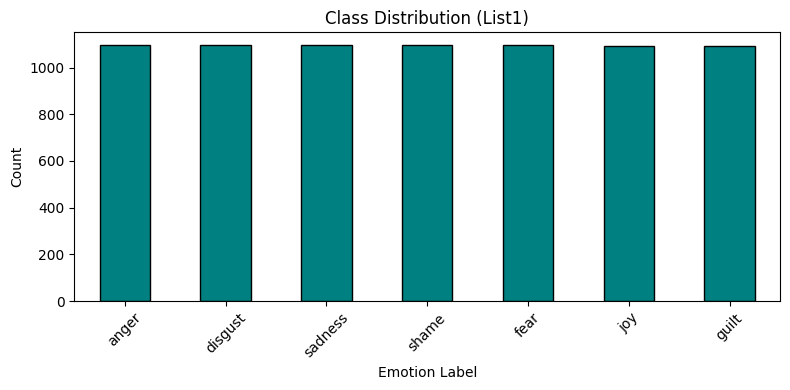

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
file_path = "/kaggle/input/emotions-description/Emotions description.xlsx"

# Show all sheet names first (optional, to confirm which sheet contains List1)
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)

# Load the 'List1' sheet
df = pd.read_excel(file_path, sheet_name="List1")

# Inspect structure
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample rows:")
print(df.head())

# Check class distribution (assuming the emotion label column is 'Field1')
print("\nClass Distribution:")
print(df['Field1'].value_counts())

# Optional visualization
plt.figure(figsize=(8, 4))
df['Field1'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title("Class Distribution (List1)")
plt.xlabel("Emotion Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Training Set Distribution:
 emotion
anger       2159
fear        1937
joy         5362
love        1304
sadness     4666
surprise     572
Name: count, dtype: int64


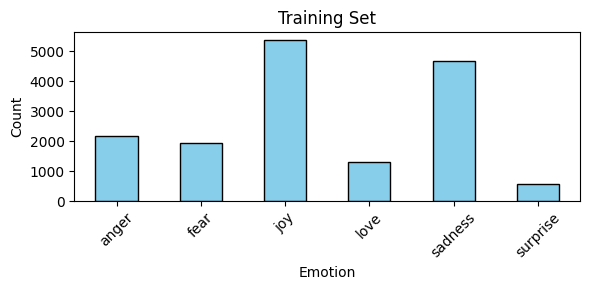


Validation Set Distribution:
 emotion
anger       275
fear        212
joy         704
love        178
sadness     550
surprise     81
Name: count, dtype: int64


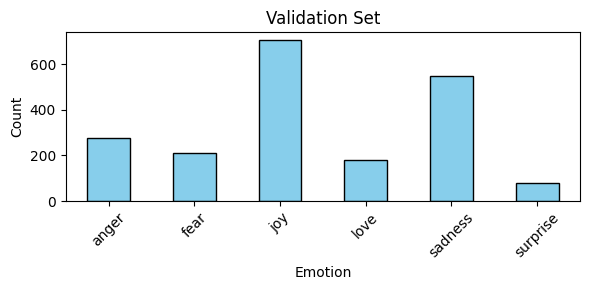


Test Set Distribution:
 emotion
anger       275
fear        224
joy         695
love        159
sadness     581
surprise     66
Name: count, dtype: int64


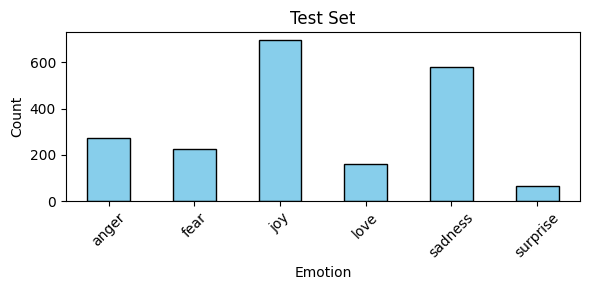


Overall Dataset Distribution:
 emotion
anger       2709
fear        2373
joy         6761
love        1641
sadness     5797
surprise     719
Name: count, dtype: int64


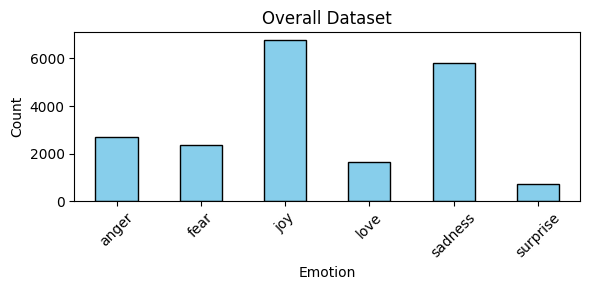

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths
train_path = "/kaggle/input/emotion-dataset/training.csv"
val_path   = "/kaggle/input/emotion-dataset/validation.csv"
test_path  = "/kaggle/input/emotion-dataset/test.csv"

# Load data
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

# Label mapping
labels_dict = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}

# Map numeric labels to emotion names
for df in [train_df, val_df, test_df]:
    df['emotion'] = df['label'].map(labels_dict)

# Function to print and visualize distribution
def plot_distribution(df, title):
    dist = df['emotion'].value_counts().sort_index()
    print(f"\n{title} Distribution:\n", dist)
    plt.figure(figsize=(6,3))
    dist.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Show each distribution
plot_distribution(train_df, "Training Set")
plot_distribution(val_df, "Validation Set")
plot_distribution(test_df, "Test Set")

# Combined distribution (optional)
combined_df = pd.concat([train_df, val_df, test_df])
plot_distribution(combined_df, "Overall Dataset")

Train shape: (9989, 11)
Dev shape: (1109, 11)
Test shape: (2610, 11)

Detected columns:
Emotion: Emotion Emotion Emotion
Sentiment: Sentiment Sentiment Sentiment

Train - Emotion distribution (Emotion):
           count  percent
Emotion                 
anger      1109    11.10
disgust     271     2.71
fear        268     2.68
joy        1743    17.45
neutral    4710    47.15
sadness     683     6.84
surprise   1205    12.06


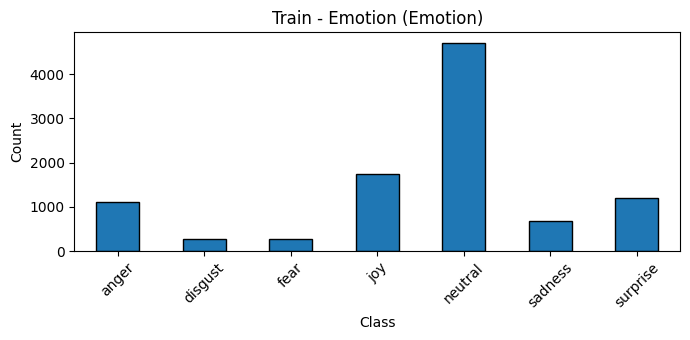


Dev - Emotion distribution (Emotion):
           count  percent
Emotion                 
anger       153    13.80
disgust      22     1.98
fear         40     3.61
joy         163    14.70
neutral     470    42.38
sadness     111    10.01
surprise    150    13.53


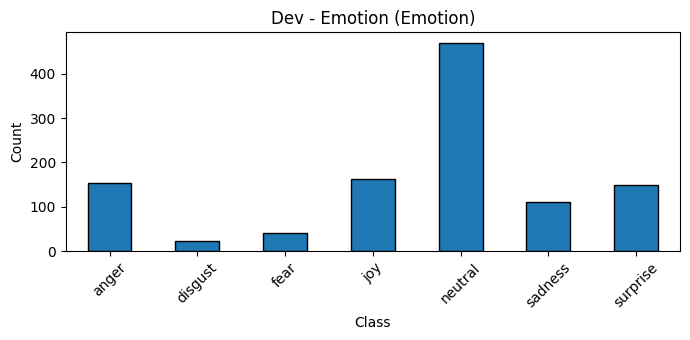


Test - Emotion distribution (Emotion):
           count  percent
Emotion                 
anger       345    13.22
disgust      68     2.61
fear         50     1.92
joy         402    15.40
neutral    1256    48.12
sadness     208     7.97
surprise    281    10.77


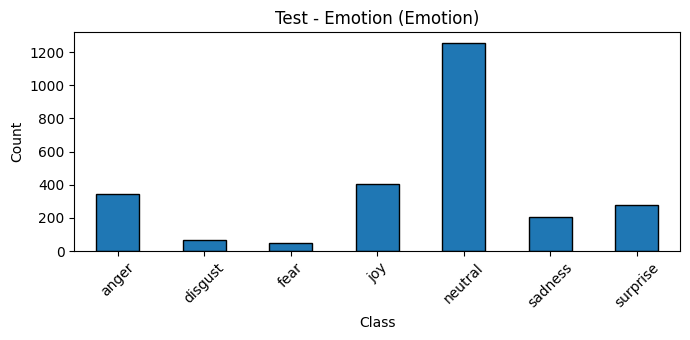


Overall - Emotion distribution (Emotion):
           count  percent
Emotion                 
anger      1607    11.72
disgust     361     2.63
fear        358     2.61
joy        2308    16.84
neutral    6436    46.95
sadness    1002     7.31
surprise   1636    11.93


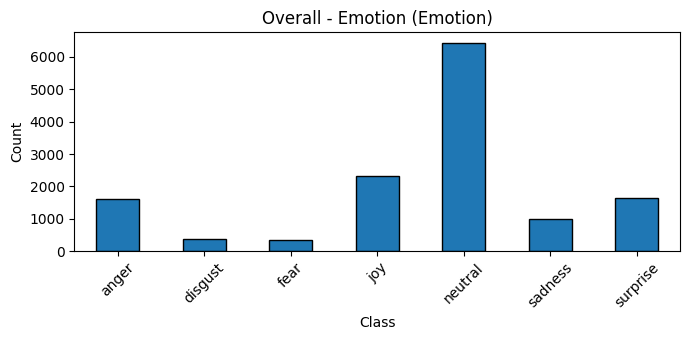


Train - Sentiment distribution (Sentiment):
            count  percent
Sentiment                
negative    2945    29.48
neutral     4710    47.15
positive    2334    23.37


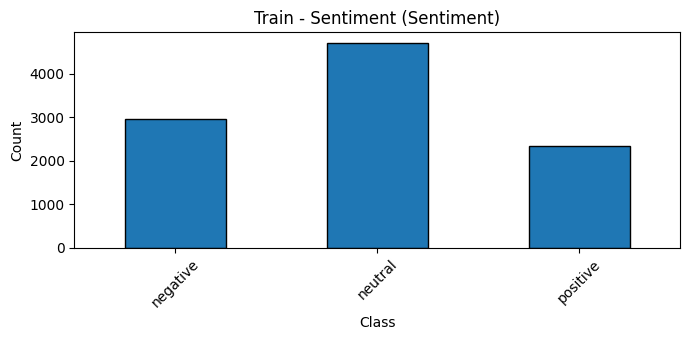


Dev - Sentiment distribution (Sentiment):
            count  percent
Sentiment                
negative     406    36.61
neutral      470    42.38
positive     233    21.01


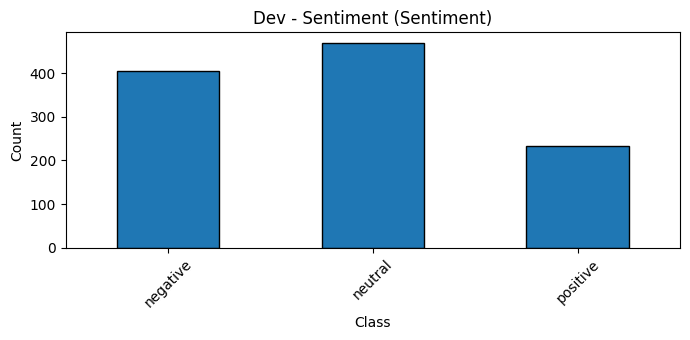


Test - Sentiment distribution (Sentiment):
            count  percent
Sentiment                
negative     833    31.92
neutral     1256    48.12
positive     521    19.96


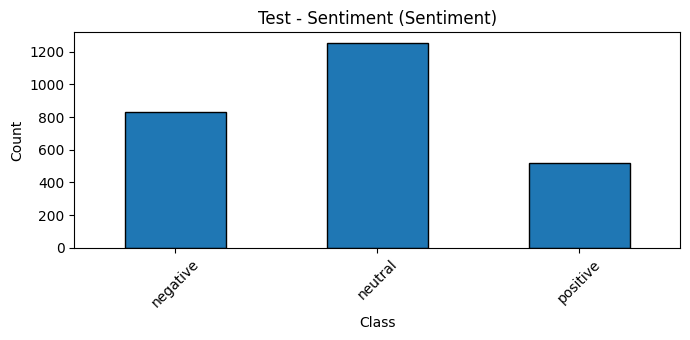


Overall - Sentiment distribution (Sentiment):
            count  percent
Sentiment                
negative    4184    30.52
neutral     6436    46.95
positive    3088    22.53


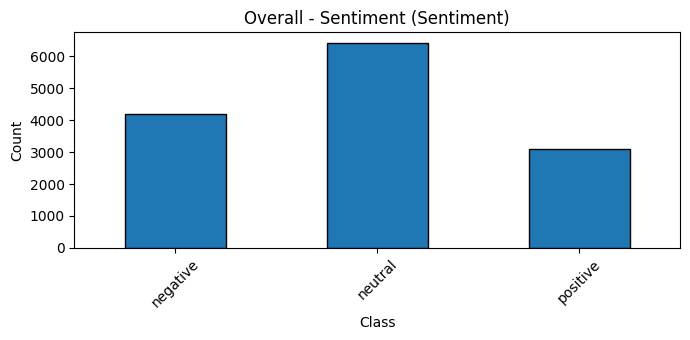

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
train_path = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_sent_emo.csv"
dev_path   = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/dev_sent_emo.csv"
test_path  = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test_sent_emo.csv"

# Load
train_df = pd.read_csv(train_path)
dev_df   = pd.read_csv(dev_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

# Helper: find a column by name, case-insensitive
def find_col(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

# Try to detect columns
emo_col_candidates = ["Emotion", "Label", "emotion", "Emo"]
sent_col_candidates = ["Sentiment", "sentiment", "Sent", "Polarity"]

emo_col_train = find_col(train_df, emo_col_candidates)
emo_col_dev   = find_col(dev_df, emo_col_candidates)
emo_col_test  = find_col(test_df, emo_col_candidates)

sent_col_train = find_col(train_df, sent_col_candidates)
sent_col_dev   = find_col(dev_df, sent_col_candidates)
sent_col_test  = find_col(test_df, sent_col_candidates)

print("\nDetected columns:")
print("Emotion:", emo_col_train, emo_col_dev, emo_col_test)
print("Sentiment:", sent_col_train, sent_col_dev, sent_col_test)

# Function to print and plot distributions
def show_distribution(df, label_col, title):
    if label_col is None or label_col not in df.columns:
        print(f"\n[{title}] '{label_col}' not found, skipping.")
        return
    dist = df[label_col].value_counts().sort_index()
    pct  = (dist / dist.sum() * 100).round(2)
    out = pd.DataFrame({"count": dist, "percent": pct})
    print(f"\n{title} distribution ({label_col}):\n", out)

    plt.figure(figsize=(7, 3.5))
    dist.plot(kind="bar", edgecolor="black")
    plt.title(f"{title} ({label_col})")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# === EMOTION distributions ===
show_distribution(train_df, emo_col_train, "Train - Emotion")
show_distribution(dev_df,   emo_col_dev,   "Dev - Emotion")
show_distribution(test_df,  emo_col_test,  "Test - Emotion")

# Combined Emotion (if columns align)
if emo_col_train and emo_col_dev and emo_col_test:
    comb_emo = pd.concat([
        train_df[[emo_col_train]].rename(columns={emo_col_train: "Emotion"}),
        dev_df[[emo_col_dev]].rename(columns={emo_col_dev: "Emotion"}),
        test_df[[emo_col_test]].rename(columns={emo_col_test: "Emotion"}),
    ], ignore_index=True)
    show_distribution(comb_emo, "Emotion", "Overall - Emotion")

# === SENTIMENT distributions (if available) ===
if sent_col_train or sent_col_dev or sent_col_test:
    show_distribution(train_df, sent_col_train, "Train - Sentiment")
    show_distribution(dev_df,   sent_col_dev,   "Dev - Sentiment")
    show_distribution(test_df,  sent_col_test,  "Test - Sentiment")

    if sent_col_train and sent_col_dev and sent_col_test:
        comb_sent = pd.concat([
            train_df[[sent_col_train]].rename(columns={sent_col_train: "Sentiment"}),
            dev_df[[sent_col_dev]].rename(columns={sent_col_dev: "Sentiment"}),
            test_df[[sent_col_test]].rename(columns={sent_col_test: "Sentiment"}),
        ], ignore_index=True)
        show_distribution(comb_sent, "Sentiment", "Overall - Sentiment")
else:
    print("\nNo sentiment column detected in any split. Skipping sentiment distributions.")